<a href="https://colab.research.google.com/github/karthikkumarp2416sse-bit/machine-learning/blob/main/EX_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
X = np.concatenate([
    np.random.randn(100, 2) + np.array([0, 0]),
    np.random.randn(100, 2) + np.array([3, 3])
])
y = np.concatenate([
    np.zeros(100),
    np.ones(100)
])

df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Target'] = y

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset shape:", df.shape)

First 5 rows of the dataset:


,Feature1,Feature2,Target
0,0.496714,-0.138264,0.0
1,0.647689,1.523030,0.0
2,-0.234153,-0.234137,0.0
3,1.579213,0.767435,0.0
4,-0.469474,0.542560,0.0



Dataset shape: (200, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 140 samples
Testing set size: 60 samples


In [ ]:
classifier = GaussianNB()

classifier.fit(X_train, y_train)

print("Naïve Bayes classifier trained successfully.")

Naïve Bayes classifier trained successfully.


In [ ]:
y_pred = classifier.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


Confusion Matrix:
[[31  0]
 [ 0 29]]

Accuracy Score: 1.0000


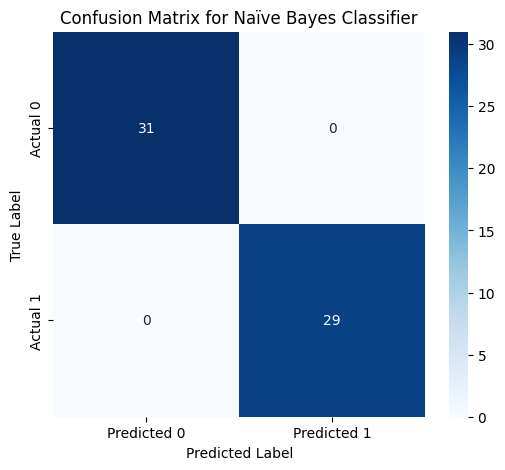

In [ ]:
cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print(f"\nAccuracy Score: {accuracy:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naïve Bayes Classifier')
plt.show()

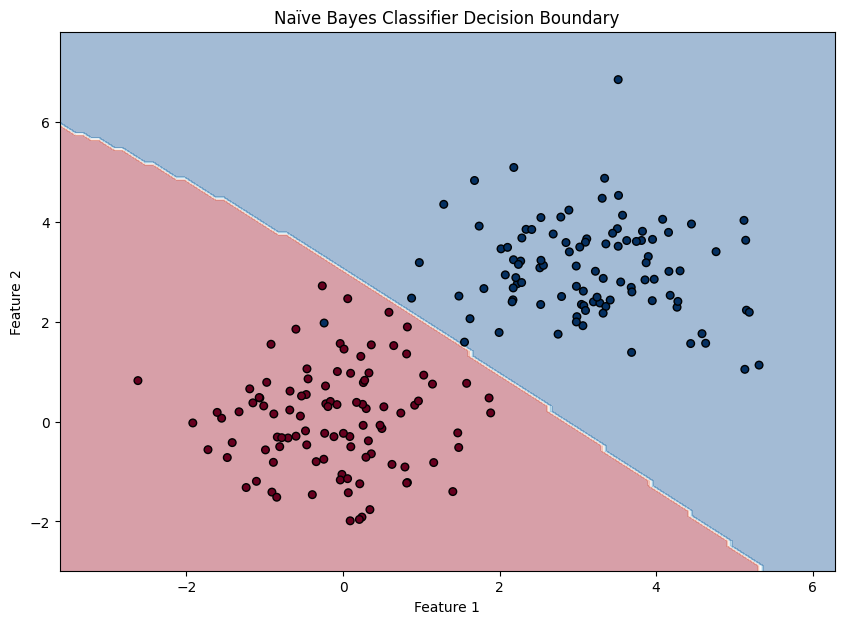

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap=plt.cm.RdBu)
plt.title('Naïve Bayes Classifier Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()